In [1]:
!pip install -qqq einops
!pip install -qqq plotly

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

import torch.nn.functional as F
import torch.optim as optim
import einops
import os
import copy

In [3]:
MODULO = 113
TRAIN_FACTOR = 0.3
HIDDEN_DIM = 256
NUM_HIDDEN_LAYERS = 1

### Generate Dataset

In [4]:
a_vector = einops.repeat(torch.arange(MODULO), "i -> (i j)", j=MODULO)
b_vector = einops.repeat(torch.arange(MODULO), "j -> (i j)", i=MODULO)
equals_vector = einops.repeat(torch.tensor(MODULO), " -> (i j)", i=MODULO, j=MODULO)
dataset = torch.stack([a_vector, b_vector, equals_vector], dim=1)
labels = (dataset[:, 0] + dataset[:, 1]) % MODULO

print(dataset.shape)
print(labels.shape)
print(dataset[:5])
print(labels[:5])

torch.Size([12769, 3])
torch.Size([12769])
tensor([[  0,   0, 113],
        [  0,   1, 113],
        [  0,   2, 113],
        [  0,   3, 113],
        [  0,   4, 113]])
tensor([0, 1, 2, 3, 4])


### Create and Load Trained Model

In [5]:
class RNNModel(nn.Module):
    def __init__(self, hidden_dim, n_layers, vocab_size):
        super(RNNModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.layer_dim = n_layers
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, n_layers, batch_first=True) # batch_first=True (batch_dim, seq_dim, feature_dim)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.bn = nn.BatchNorm1d(hidden_dim)

    def forward(self, tokens):
        xs = self.embedding(tokens)
        hs, hn = self.rnn(xs)
        hs = self.bn(hs[:, -1, :])
        scores = self.fc(hs)
        return scores

model = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
print(model)

RNNModel(
  (embedding): Embedding(114, 256)
  (rnn): RNN(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=114, bias=True)
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [7]:
# drive.mount('/content/drive', force_remount=True)

In [8]:
import os

path_Check = "/content/drive/MyDrive/workspace/grokking_rnn_large_256_0.3.pth"
print(os.path.exists(path_Check))

False


In [10]:
import os
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive') # Uncomment this line to mount Google Drive

PTH_LOCATION = f"workspace/_scratch/grokking_rnn_large_{HIDDEN_DIM}_0.3.pth"

# Correct the file path by joining the base path and PTH_LOCATION
file_path = os.path.join("/content/drive/MyDrive/", PTH_LOCATION)

cached_data = torch.load(file_path, map_location=torch.device('cpu'))

model.load_state_dict(cached_data['model'])

Mounted at /content/drive


<ipython-input-10-092e96046769>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cached_data = torch.load(file_path, map_location=torch.device('cpu'))


<All keys matched successfully>

### Evaluate on Dataset

In [11]:
# evaluation function that provides the accuracy of the model
def evaluate(test_model, data, labels):
    test_model.eval()
    with torch.no_grad():
        logits = test_model(data)
        predictions = logits.argmax(dim=-1)
        correct = (predictions == labels).sum().item()
        total = len(labels)
        accuracy = correct / total * 100
        return accuracy

# evaluate the model on the test set
evaluation = evaluate(model, dataset, labels)
print(f"Accuracy: {evaluation}%")

Accuracy: 100.0%


### Fourier Analysis Utils

In [12]:
from pandas import melt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def embed_to_cos_sin(fourier_embed):
    if len(fourier_embed.shape) == 1:
        return torch.stack([fourier_embed[1::2], fourier_embed[2::2]])
    else:
        return torch.stack([fourier_embed[:, 1::2], fourier_embed[:, 2::2]], dim=1)

def plot_embed_bars(fourier_embed, title='Norm of embedding of each Fourier Component', return_fig=False, **kwargs):
    cos_sin_embed = embed_to_cos_sin(fourier_embed)
    # Convert the tensor to a NumPy array and then to a DataFrame
    cos_sin_embed_np = cos_sin_embed.cpu().detach().numpy() # Move tensor to CPU and convert to NumPy array
    df = melt(pd.DataFrame(cos_sin_embed_np)) # Create DataFrame from NumPy array and melt
    return df.groupby('variable').mean().plot(kind='bar', title=title, **kwargs)

def fourier_basis_constructor(p):
    fourier_basis = []
    fourier_basis.append(torch.ones(p)/np.sqrt(p))
    fourier_basis_names = ['Const']
    for i in range(1, p//2 +1):
        fourier_basis.append(torch.cos(2*torch.pi*torch.arange(p)*i/p))
        fourier_basis.append(torch.sin(2*torch.pi*torch.arange(p)*i/p))
        fourier_basis[-2]/=fourier_basis[-2].norm()
        fourier_basis[-1]/=fourier_basis[-1].norm()
        fourier_basis_names.append(f'cos {i}')
        fourier_basis_names.append(f'sin {i}')

    return fourier_basis, fourier_basis_names

p=113
fourier_basis, fourier_basis_names = fourier_basis_constructor(p)
fourier_basis = torch.stack(fourier_basis).cpu()

def fft2d(mat):
    # Converts a pxpx... or batch x ... tensor into the 2D Fourier basis.
    # Output has the same shape as the original
    shape = mat.shape
    mat = einops.rearrange(mat, '(x y) ... -> x y (...)', x=p, y=p)
    fourier_mat = torch.einsum('xyz,fx,Fy->fFz', mat.to(torch.float), fourier_basis.to(torch.float), fourier_basis.to(torch.float))
    return fourier_mat.reshape(shape)

def unflatten_first(tensor):
    if tensor.shape[0]==p*p:
        return einops.rearrange(tensor, '(x y) ... -> x y ...', x=p, y=p)
    else:
        return tensor

def to_numpy(tensor, flat=False):
    if isinstance(tensor, np.ndarray):
        return tensor
    elif isinstance(tensor, list):
        # if isinstance(tensor[0])
        return np.array(tensor)
    elif isinstance(tensor, torch.Tensor):
        if flat:
            return tensor.flatten().detach().cpu().numpy()
        else:
            return tensor.detach().cpu().numpy()
    else:
        raise ValueError(f"Input to to_numpy has invalid type: {type(tensor)}")

def imshow_fourier(tensor, title='', animation_name='snapshot', facet_labels=[], exclude_const=False, return_fig=False, **kwargs):
    # Set nice defaults for plotting functions in the 2D fourier basis
    # tensor is assumed to already be in the Fourier Basis
    if tensor.shape[0]==p*p:
        tensor = unflatten_first(tensor)
    tensor = torch.squeeze(tensor)
    if exclude_const:
        T = tensor[1:, 1:]
        names = fourier_basis_names[1:]
    else:
        T = tensor
        names = fourier_basis_names

    fig=px.imshow(to_numpy(T),
            x=names,
            y=names,
            labels={'x':'x Component',
                    'y':'y Component',
                    'animation_frame':animation_name},
            title=title,
            color_continuous_midpoint=0.,
            color_continuous_scale='RdBu',
            **kwargs)
    fig.update(data=[{'hovertemplate':"%{x}x * %{y}y<br>Value:%{z:.4f}"}])
    if facet_labels:
        for i, label in enumerate(facet_labels):
            fig.layout.annotations[i]['text'] = label
    fig = fig
    if return_fig:
        return fig
    else:
        fig.show("vscode+colab")

### Fourier Analysis of Modular Addition RNN

#### Sparse Fourier Spectra in embeddings and hidden states

We show that the embedding matrix, unembedding matrix, and hidden states of the RNN are all sparse in the fourier spectrum, using the same frequencies

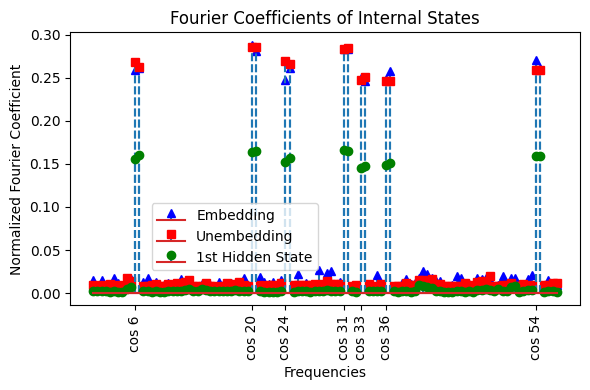

In [13]:
W_E = cached_data['model']['embedding.weight']
W_fc = cached_data['model']['fc.weight']
W_ih = cached_data['model']['rnn.weight_ih_l0']
W_hh = cached_data['model']['rnn.weight_hh_l0']

# W_E = model.embedding.weight[:-1].cpu()
# W_fc = model.fc.weight[:-1].cpu()
# W_ih = model.rnn.weight_ih_l0.cpu()
# W_hh = model.rnn.weight_hh_l0.cpu()
# ip_layer_embeds = W_E @ W_ih.cpu()

model.eval()
with torch.no_grad():
    embedded_seq = model.embedding(dataset)
    output, hidden_states = model.rnn(embedded_seq)


# Assuming fourier_basis is defined and available
# Compute Fourier Transform of embeddings and hidden states
fourier_transformed_embeddings = fourier_basis @ W_E[:-1,:]
fourier_transformed_fc = fourier_basis @ W_fc[:-1,:]
fourier_transformed_h1 = fourier_basis @ output[::113,0,:]

# Compute norms
coeffs_embed = fourier_transformed_embeddings.norm(dim=1)
coeffs_fc = fourier_transformed_fc.norm(dim=1)
coeffs_h1 = fourier_transformed_h1.norm(dim=1)

# Apply threshold to identify key frequencies
key_freqs_embed = torch.where(coeffs_embed > 2, 1, 0).nonzero()
key_freqs_fc = torch.where(coeffs_fc > 1, 1, 0).nonzero()
key_freqs_h1 = torch.where(coeffs_h1 > 0.2, 1, 0).nonzero()

key_freqs = key_freqs_embed.squeeze().detach().numpy() - 1
# plot norms
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=(6, 4))

plt.stem(range(MODULO-1), (coeffs_embed/coeffs_embed.norm()).detach().numpy()[1:], markerfmt='b^', linefmt='--', label='Embedding')
plt.stem(range(MODULO-1), (coeffs_fc/coeffs_fc.norm()).detach().numpy()[1:], markerfmt='rs', linefmt='--', label='Unembedding')
plt.stem(range(MODULO-1), (coeffs_h1/coeffs_h1.norm()).detach().numpy()[1:], markerfmt='go', linefmt='--', label='1st Hidden State')
plt.legend(loc='best', bbox_to_anchor=(0.5, 0.4))

plt.xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=90)
plt.xlabel('Frequencies')
plt.ylabel('Normalized Fourier Coefficient')
plt.title('Fourier Coefficients of Internal States')
plt.tight_layout()
plt.show()
# plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients.pdf')


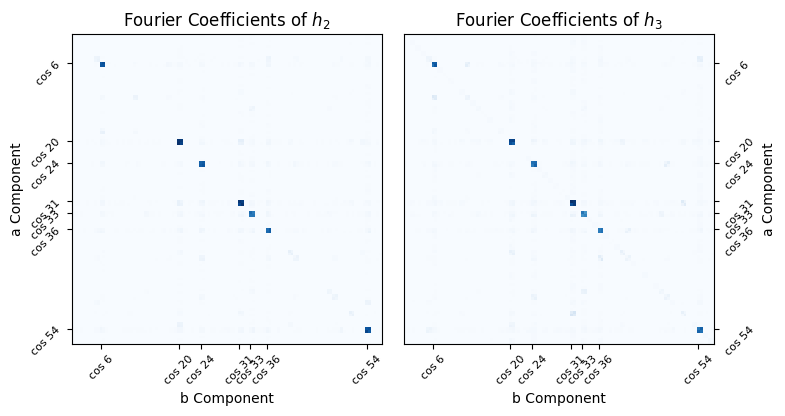

In [14]:
fourier_transformed_h2 = fft2d(output[:,1,:]).norm(dim=-1).reshape(p,p).detach().numpy()
fourier_transformed_h3 = fft2d(output[:,2,:]).norm(dim=-1).reshape(p,p).detach().numpy()

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# plt.figure(figsize=(4, 4))
axs[0].matshow(fourier_transformed_h2[1:,1:], cmap='Blues')
axs[0].set_ylabel('a Component')
axs[0].xaxis.set_label_position('bottom')
axs[0].set_xlabel('b Component')
axs[0].xaxis.tick_bottom()
axs[0].set_xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
axs[0].set_yticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
axs[0].set_title('Fourier Coefficients of $h_2$')
# plt.tight_layout()
# plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients_h2.pdf')

# plt.figure(figsize=(4, 4))
axs[1].matshow(fourier_transformed_h3[1:,1:], cmap='Blues')
axs[1].yaxis.set_label_position('right')
axs[1].set_ylabel('a Component')
axs[1].xaxis.set_label_position('bottom')
axs[1].set_xlabel('b Component')
axs[1].xaxis.tick_bottom()
axs[1].yaxis.tick_right()
axs[1].set_xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
axs[1].set_yticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
axs[1].set_title('Fourier Coefficients of $h_3$')

plt.tight_layout()
# plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients_h2h3.pdf')
# plt.show()

#### Analysis of SVD Components

Here we show that all weight matrices in the network are low rank.

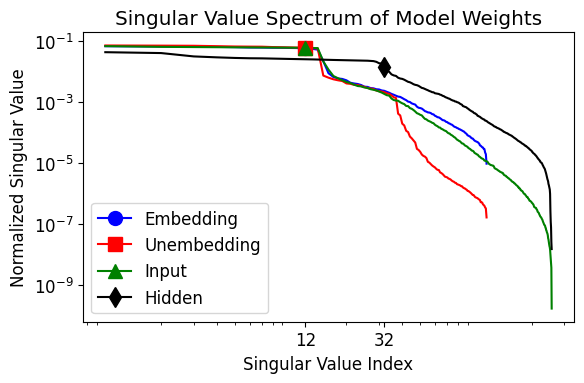

In [15]:
W_E = cached_data['model']['embedding.weight']
W_fc = cached_data['model']['fc.weight']
W_ih = cached_data['model']['rnn.weight_ih_l0']
W_hh = cached_data['model']['rnn.weight_hh_l0']

with torch.no_grad():
    U_E, S_E, Vh_E = torch.linalg.svd(W_E, full_matrices=False)
    U_fc, S_fc, Vh_fc = torch.linalg.svd(W_fc, full_matrices=False)
    U_ih, S_ih, Vh_ih = torch.linalg.svd(W_ih, full_matrices=False)
    U_hh, S_hh, Vh_hh = torch.linalg.svd(W_hh, full_matrices=False)

ip_idxs = np.arange(1, min(MODULO+2, HIDDEN_DIM+1))
hh_idxs = np.arange(1, HIDDEN_DIM+1)
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(6, 4))

plt.loglog(ip_idxs, (S_E/S_E.sum()).detach().numpy(), 'b-')
plt.loglog(ip_idxs, (S_fc/S_fc.sum()).detach().numpy(), 'r-')
plt.loglog(hh_idxs, (S_ih/S_ih.sum()).detach().numpy(), 'g-')
plt.loglog(hh_idxs, (S_hh/S_hh.sum()).detach().numpy(), 'k-')
plt.plot(12, (S_E[11]/S_E.sum()).detach().numpy(), marker='o', markersize=10, color='b', label='Embedding')
plt.plot(12, (S_fc[11]/S_fc.sum()).detach().numpy(), marker='s', markersize=10, color='r', label='Unembedding')
plt.plot(12, (S_ih[11]/S_ih.sum()).detach().numpy(), marker='^', markersize=10, color='g', label='Input')
plt.plot(32, (S_hh[31]/S_hh.sum()).detach().numpy(), marker='d', markersize=10, color='k', label='Hidden')
plt.xticks([12 ,32], labels=['12', '32'])
plt.xlabel('Singular Value Index')
plt.ylabel('Normalized Singular Value')
plt.title('Singular Value Spectrum of Model Weights')
plt.legend()
# plt.show()
plt.tight_layout()
# plt.savefig('drive/MyDrive/workspace/icassp25/singular_value_spectrum.pdf')

In [16]:
embed_comps = 12
fc_comps = 12
hh_comps = 50

print(S_E[:embed_comps].sum()/S_E.sum())
print(S_fc[:fc_comps].sum()/S_fc.sum())
print(S_ih[:embed_comps].sum()/S_ih.sum())
print(S_hh[:hh_comps].sum()/S_hh.sum())

tensor(0.7617)
tensor(0.8021)
tensor(0.7663)
tensor(0.9226)


Ablating the unimportant components of the weight matrices does not affect the accuracy.

In [17]:
from copy import deepcopy
model_weights = deepcopy(cached_data['model'])

embed_comps = 16
fc_comps = 16
hh_comps = 44

model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
model_weights['fc.weight'] = U_fc[:,:fc_comps] @ torch.diag(S_fc[:fc_comps]) @ Vh_fc[:fc_comps,:]
model_weights['rnn.weight_ih_l0'] = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
model_weights['rnn.weight_hh_l0'] = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
model_trunc.load_state_dict(model_weights)

evaluation_trunc = evaluate(model_trunc, dataset, labels)
print(f"Accuracy: {evaluation_trunc}%")

Accuracy: 100.0%


However, ablating all the important components does affect the accuracy.

In [18]:
from copy import deepcopy
model_weights = deepcopy(cached_data['model'])

embed_comps = 16
fc_comps = 16
hh_comps = 44

model_weights['embedding.weight'] = U_E[:,embed_comps:] @ torch.diag(S_E[embed_comps:]) @ Vh_E[embed_comps:,:]
model_weights['fc.weight'] = U_fc[:,fc_comps:] @ torch.diag(S_fc[fc_comps:]) @ Vh_fc[fc_comps:,:]
model_weights['rnn.weight_ih_l0'] = U_ih[:,embed_comps:] @ torch.diag(S_ih[embed_comps:]) @ Vh_ih[embed_comps:,:]
model_weights['rnn.weight_hh_l0'] = U_hh[:,hh_comps:] @ torch.diag(S_hh[hh_comps:]) @ Vh_hh[hh_comps:,:]

model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
model_trunc.load_state_dict(model_weights)

evaluation_trunc = evaluate(model_trunc, dataset, labels)
print(f"Accuracy: {evaluation_trunc}%")

Accuracy: 0.8849557522123894%


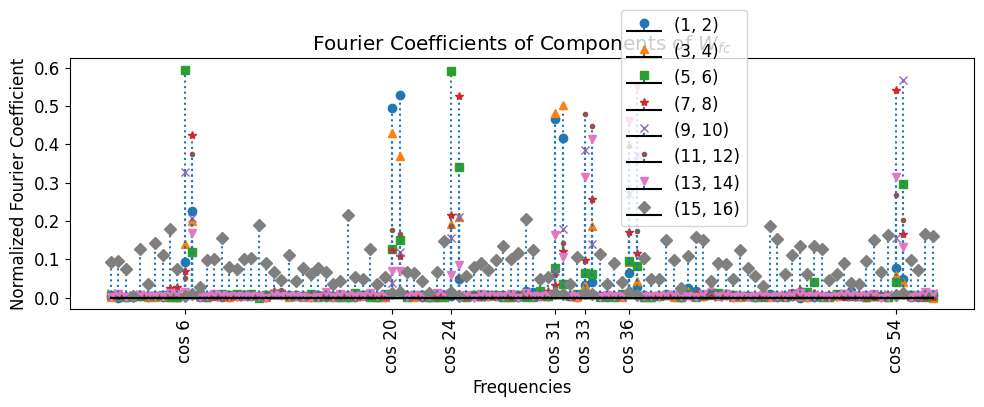

In [24]:
colors = ['b','r','g','m','k','y', 'c', 'orange'] # Extended color list
markers = ['o', '^', 's', '*', 'x', '.', 'v', 'D'] # Extended marker list
plt.figure(figsize=(10,4))
for i in range(8):
  W_fc_trunc = U_fc[:,2*i:2*(i+1)] @ torch.diag(S_fc[2*i:2*(i+1)]) @ Vh_fc[2*i:2*(i+1),:]
  fourier_transformed_fc_trunc = fourier_basis @ W_fc_trunc[:-1,:]
  coeffs_trunc_fc = fourier_transformed_fc_trunc.norm(dim=1)

  # plot norms
  # Use only the marker symbol, not the color and marker together
  markerfmt = markers[i]
  plt.stem(range(MODULO-1), (coeffs_trunc_fc/coeffs_trunc_fc.norm()).detach().numpy()[1:], markerfmt=markerfmt, linefmt=':', basefmt='k-', label=f'{2*i+1, 2*i+2}')

plt.xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=90)
plt.xlabel('Frequencies')
plt.ylabel('Normalized Fourier Coefficient')
plt.title('Fourier Coefficients of Components of $W_{fc}$') # Fixed typo in title
plt.legend(loc='best', bbox_to_anchor=(0.6, 0.3))
plt.tight_layout()
# plt.savefig('drive/MyDrive/workspace/icassp25/fourier_components_fc.pdf')

In [25]:
embed_comps = 16
fc_comps = 16
hh_comps = 50

for i in range(8):
  with torch.no_grad():
    model_weights = deepcopy(cached_data['model'])
    model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
    model_weights['rnn.weight_ih_l0'] = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
    model_weights['rnn.weight_hh_l0'] = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

    S_fc_trunc = torch.clone(S_fc[:fc_comps])
    S_fc_trunc[2*i:2*(i+1)] = 0
    W_fc_trunc = U_fc[:,:fc_comps] @ torch.diag(S_fc_trunc) @ Vh_fc[:fc_comps,:]
    model_weights['fc.weight'] = W_fc_trunc

    model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
    model_trunc.load_state_dict(model_weights)

    evaluation_trunc = evaluate(model_trunc, dataset, labels)
    print(f"Accuracy after ablating freq {i+1}: {evaluation_trunc}%")

Accuracy after ablating freq 1: 98.89576317644296%
Accuracy after ablating freq 2: 97.1963348735218%
Accuracy after ablating freq 3: 100.0%
Accuracy after ablating freq 4: 98.94275197744537%
Accuracy after ablating freq 5: 99.20902184979246%
Accuracy after ablating freq 6: 99.9373482653301%
Accuracy after ablating freq 7: 100.0%
Accuracy after ablating freq 8: 100.0%


In [26]:
embed_comps = 16
fc_comps = 16
hh_comps = 50

for i in range(8):
  with torch.no_grad():
    model_weights = deepcopy(cached_data['model'])
    model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
    model_weights['rnn.weight_ih_l0'] = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
    model_weights['rnn.weight_hh_l0'] = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

    S_fc_trunc = torch.clone(S_fc[:fc_comps])
    S_fc_trunc[:2*(i+1)] = 0
    W_fc_trunc = U_fc[:,:fc_comps] @ torch.diag(S_fc_trunc) @ Vh_fc[:fc_comps,:]
    model_weights['fc.weight'] = W_fc_trunc

    model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
    model_trunc.load_state_dict(model_weights)

    evaluation_trunc = evaluate(model_trunc, dataset, labels)
    print(f"Accuracy after ablating freq {i+1}: {evaluation_trunc}%")

Accuracy after ablating freq 1: 98.89576317644296%
Accuracy after ablating freq 2: 91.21309421254601%
Accuracy after ablating freq 3: 82.82559323361266%
Accuracy after ablating freq 4: 51.16297282481008%
Accuracy after ablating freq 5: 25.969144020675074%
Accuracy after ablating freq 6: 6.735061477014645%
Accuracy after ablating freq 7: 0.5247082778604433%
Accuracy after ablating freq 8: 0.8849557522123894%


### Show that $V_{fc}^T h_3$ is $cos(w_k(a+b))+sin(w_k(a+b))$

In [27]:
with torch.no_grad():
    embedded_seq = model.embedding(dataset)
    output, hidden_states = model.rnn(embedded_seq)
    h3_norm = model.bn(output[:,2,:])
    plotting_coeffs = torch.zeros(h3_norm.shape[0], 2)
    for i in range(8):
        plotting_coeffs += fft2d(h3_norm @ Vh_fc[2*i:2*(i+1)].t())
        # imshow_fourier(fft2d(h3_norm @ Vh_fc[2*i:2*(i+1)].t())[:,0], exclude_const=True)
plotting_coeffs = plotting_coeffs.reshape(p,p,2)
res_cos = torch.zeros(8,2)
res_sin = torch.zeros(8,2)
coeff_cos = torch.zeros(8,2)
coeff_sin = torch.zeros(8,2)
for i in range(6):
    res_cos[i] = 0.5*(plotting_coeffs[key_freqs[2*i]+1, key_freqs[2*i]+1] + plotting_coeffs[key_freqs[2*i+1]+1, key_freqs[2*i+1]+1])
    res_sin[i] = 0.5*(plotting_coeffs[key_freqs[2*i+1]+1, key_freqs[2*i]+1] - plotting_coeffs[key_freqs[2*i]+1, key_freqs[2*i+1]+1])
    coeff_cos[i] = 0.5*(plotting_coeffs[key_freqs[2*i]+1, key_freqs[2*i]+1] - plotting_coeffs[key_freqs[2*i+1]+1, key_freqs[2*i+1]+1])
    coeff_sin[i] = 0.5*(plotting_coeffs[key_freqs[2*i+1]+1, key_freqs[2*i]+1] + plotting_coeffs[key_freqs[2*i]+1, key_freqs[2*i+1]+1])
    rel_error = (res_cos[i].pow(2).sum()+res_sin[i].pow(2).sum())/(coeff_cos[i].pow(2).sum()+coeff_sin[i].pow(2).sum())
    print(f'Relative Error for components {fourier_basis_names[key_freqs[2*i]+1], fourier_basis_names[key_freqs[2*i+1]+1]}: {rel_error.sqrt():E}')

# rel_error = (res_cos.pow(2).sum()+res_sin.pow(2).sum())/(coeff_cos.pow(2).sum()+coeff_sin.pow(2).sum())
# print(rel_error)


Relative Error for components ('cos 6', 'sin 6'): 5.632903E-03
Relative Error for components ('cos 20', 'sin 20'): 1.146830E-02
Relative Error for components ('cos 24', 'sin 24'): 1.789631E-02
Relative Error for components ('cos 31', 'sin 31'): 3.810441E-02
Relative Error for components ('cos 33', 'sin 33'): 2.812091E-02
Relative Error for components ('cos 36', 'sin 36'): 2.169317E-02


In [28]:
imshow_fourier(plotting_coeffs.reshape(p*p,2)[:,0], exclude_const=True)
imshow_fourier(plotting_coeffs.reshape(p*p,2)[:,1], exclude_const=True)

Ablating components of $W_E$

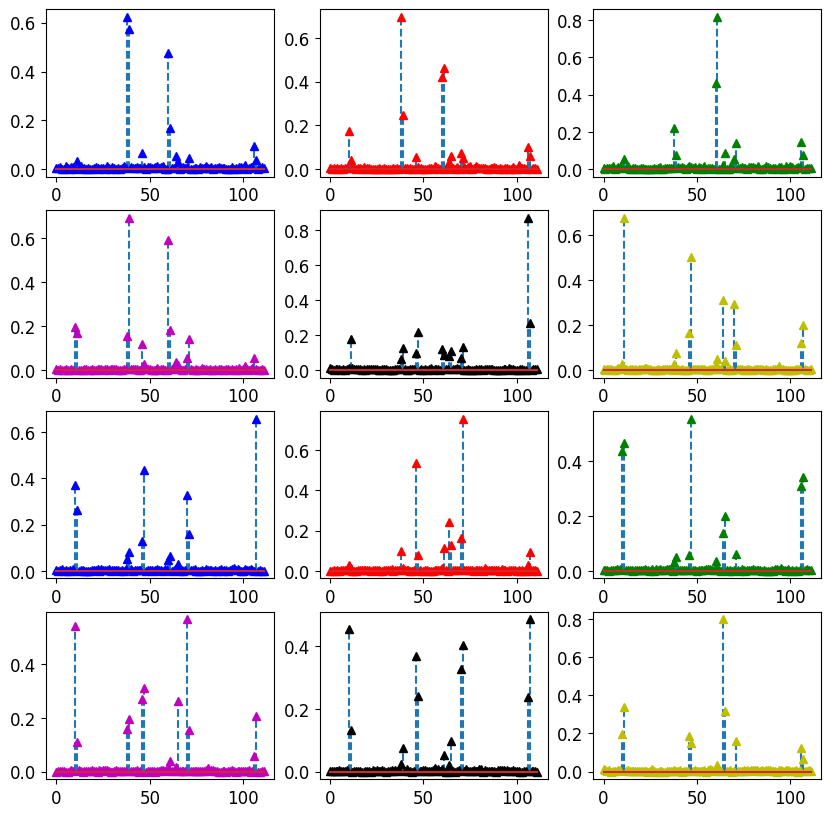

In [29]:
colors = ['b','r','g','m','k','y']
fig, axs = plt.subplots(4,3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()):
  # W_E_trunc = U_E[:,i] @ torch.diag(S_E[i]) @ Vh_E[i,:]
  W_E_trunc = S_E[i] * torch.outer(U_E[:,i], Vh_E[i,:])
  fourier_transformed_E_trunc = fourier_basis @ W_E_trunc[:-1,:]
  coeffs_trunc_E = fourier_transformed_E_trunc.norm(dim=1)

  # plot norms
  ax.stem(range(MODULO-1), (coeffs_trunc_E/coeffs_trunc_E.norm()).detach().numpy()[1:], markerfmt=''.join([colors[i % 6],'^']), linefmt='--', label=f'{i}')

# plt.xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=90)
# plt.xlabel('Frequencies')
# plt.ylabel('Normalized Fourier Coefficient')
# plt.title('Fourier Coefficients of Components of $W_{E}$')
# plt.legend(loc='best')

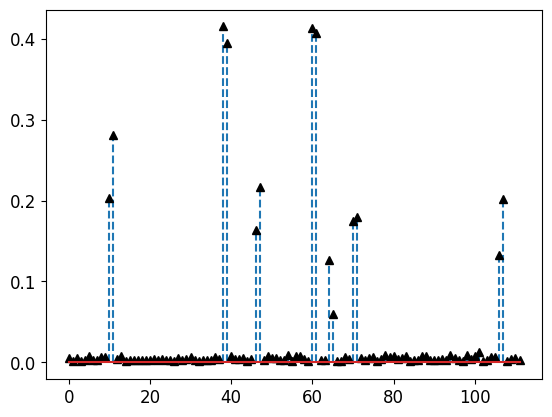

In [30]:
embed_comps = 12
fc_comps = 12
hh_comps = 32

# ablate_idxs = [1,4,6,9,11] # 6
ablate_idxs = [4,6,7,8,9,11] # 15
# ablate_idxs = [3,4,7,8,11] # 20
# ablate_idxs = [0,2,4,5,10,11] # 29
# ablate_idxs = [0,2,4,5,11] # 47
# ablate_idxs = [1,3,4,10,11] # 54

with torch.no_grad():
  W_E_trunc = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
  for j in ablate_idxs:
    W_E_trunc -= S_E[j] * torch.outer(U_E[:,j], Vh_E[j,:])

  fourier_transformed_E_trunc = fourier_basis @ W_E_trunc[:-1,:]
  coeffs_trunc_E = fourier_transformed_E_trunc.norm(dim=1)

  # plot norms
  plt.stem(range(MODULO-1), (coeffs_trunc_E/coeffs_trunc_E.norm()).detach().numpy()[1:], markerfmt='k^', linefmt='--')
  plt.show()


Ablating components of $W_{ih}$

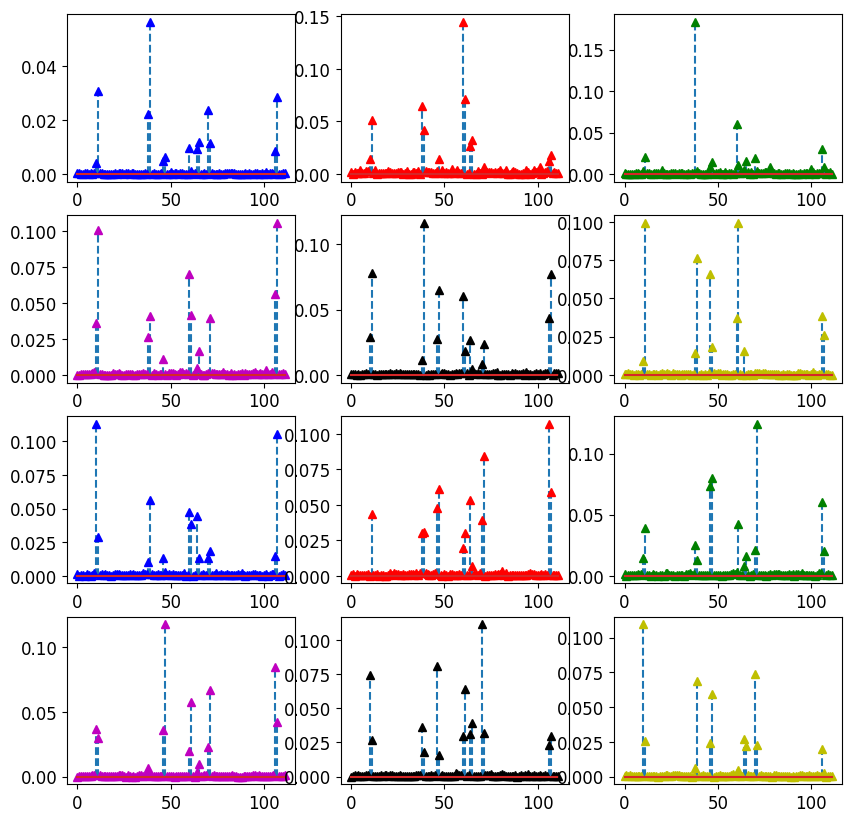

In [31]:
embed_comps = 12
fc_comps = 12
hh_comps = 30

colors = ['b','r','g','m','k','y']
fig, axs = plt.subplots(4,3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()):
  with torch.no_grad():
    model_weights = deepcopy(cached_data['model'])
    model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
    model_weights['fc.weight'] = U_fc[:,:fc_comps] @ torch.diag(S_fc[:fc_comps]) @ Vh_fc[:fc_comps,:]
    # model_weights['rnn.weight_ih_l0'] = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
    model_weights['rnn.weight_hh_l0'] = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

    # S_ih_trunc = torch.zeros_like(S_ih[:embed_comps])
    # S_ih_trunc[2*i:2*(i+1)] = torch.clone(S_ih[2*i:2*(i+1)])
    # W_ih_trunc = U_ih[:,:embed_comps] @ torch.diag(S_ih_trunc) @ Vh_ih[:embed_comps,:]
    W_ih_trunc = S_ih[i] * torch.outer(U_ih[:,i], Vh_ih[i,:])
    model_weights['rnn.weight_ih_l0'] = W_ih_trunc

    model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
    model_trunc.load_state_dict(model_weights)

    embedded_seq = model_trunc.embedding(dataset)
    output, hidden_states = model_trunc.rnn(embedded_seq)
    h1 = output[::113,0,:]
    plotting_coeffs = (fourier_basis @ h1).norm(dim=1)
    ax.stem(range(MODULO-1), (plotting_coeffs/plotting_coeffs.norm()).detach().numpy()[1:], markerfmt=colors[i%6]+'^', linefmt='--')

# plt.legend(loc='best')

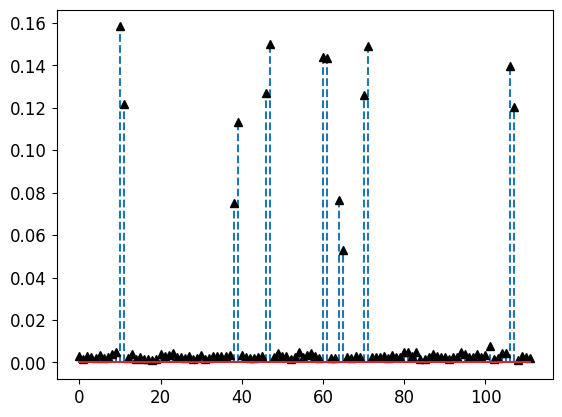

In [32]:
embed_comps = 12
fc_comps = 12
hh_comps = 32

# ablate_idxs = [4,6,8,11] # 6
# ablate_idxs = [4,5,6,7,10,11] # 15
ablate_idxs = [0,2,3,4] # 29
# ablate_idxs = [0,1,2,5] # 47

with torch.no_grad():
  model_weights = deepcopy(cached_data['model'])
  model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
  model_weights['fc.weight'] = U_fc[:,:fc_comps] @ torch.diag(S_fc[:fc_comps]) @ Vh_fc[:fc_comps,:]
  W_ih_trunc = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
  model_weights['rnn.weight_hh_l0'] = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

  for j in ablate_idxs:
    W_ih_trunc -= S_ih[j] * torch.outer(U_ih[:,j], Vh_ih[j,:])

  model_weights['rnn.weight_ih_l0'] = W_ih_trunc

  model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
  model_trunc.load_state_dict(model_weights)

  embedded_seq = model_trunc.embedding(dataset)
  output, hidden_states = model_trunc.rnn(embedded_seq)
  h1 = output[::113,0,:]
  plotting_coeffs = (fourier_basis @ h1).norm(dim=1)
  plt.stem(range(MODULO-1), (plotting_coeffs/plotting_coeffs.norm()).detach().numpy()[1:], markerfmt='k^', linefmt='--')
  plt.show()


Ablating components of $W_{hh}$

<ipython-input-33-e3cec30fccb0>:24: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



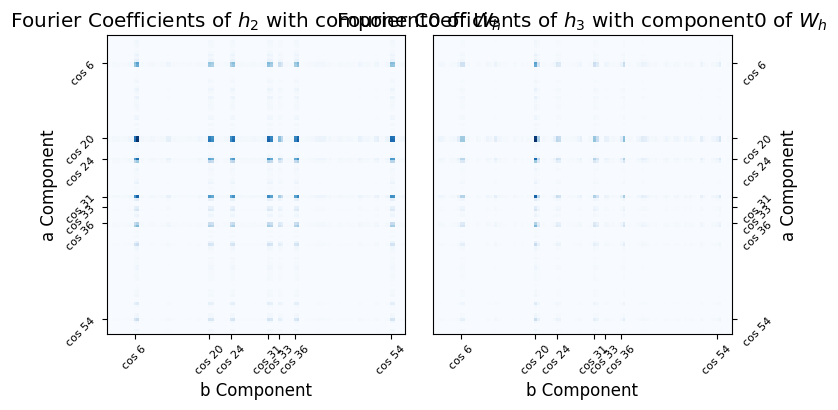

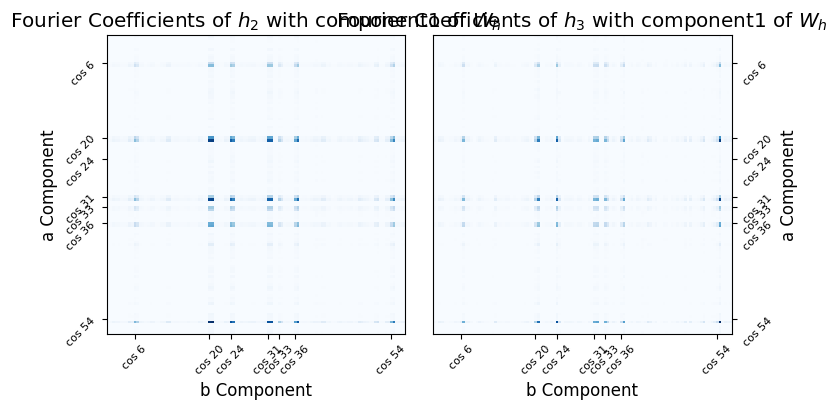

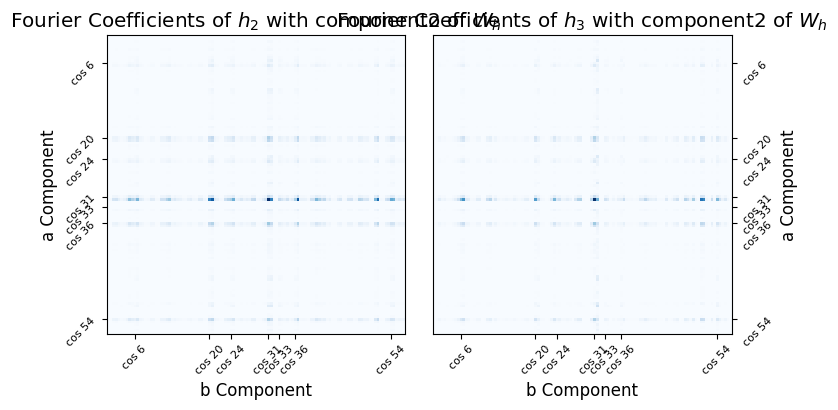

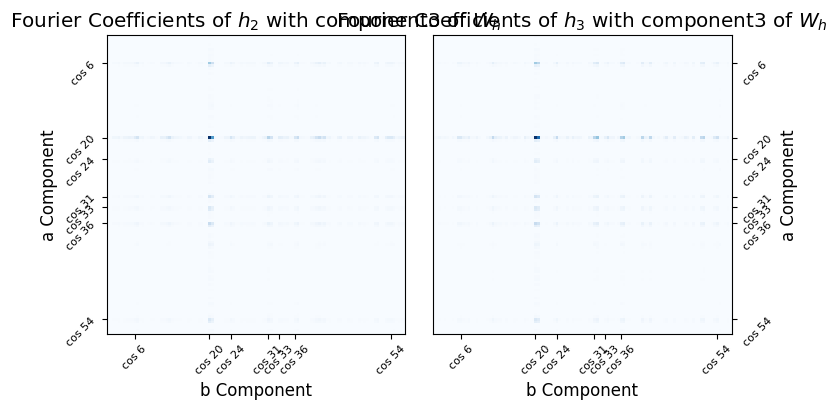

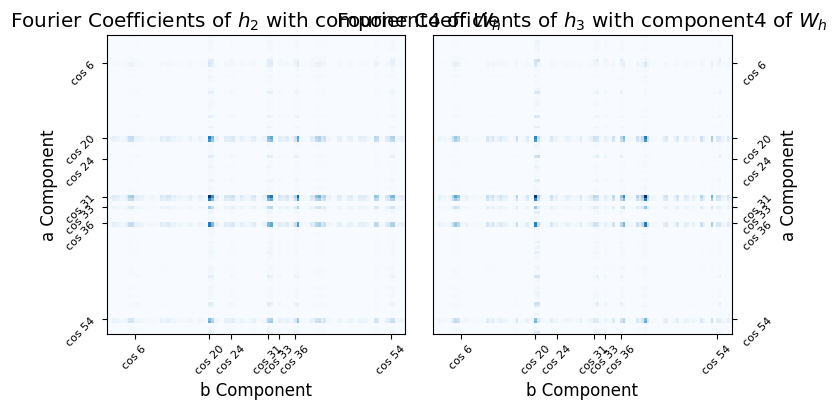

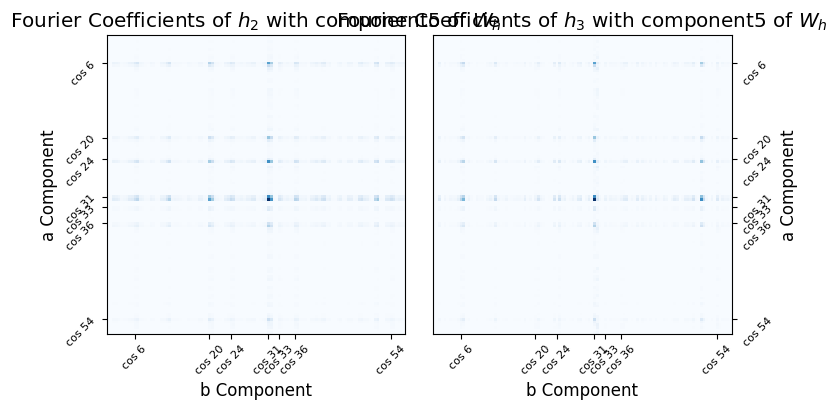

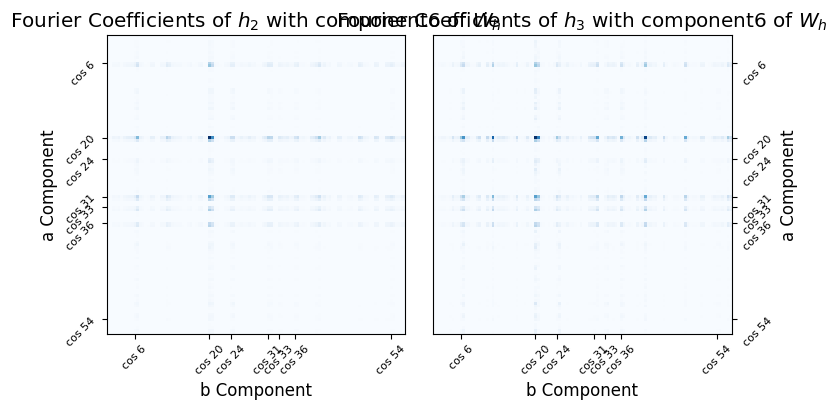

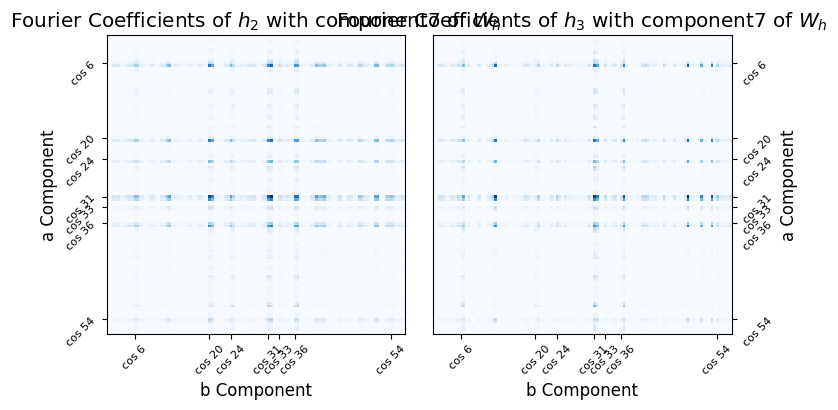

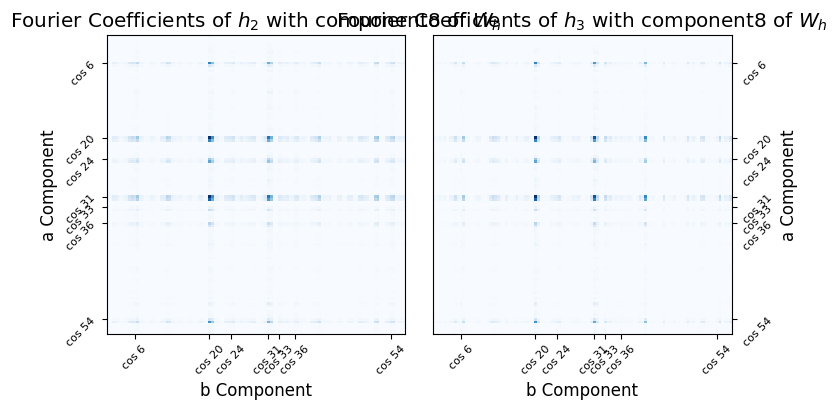

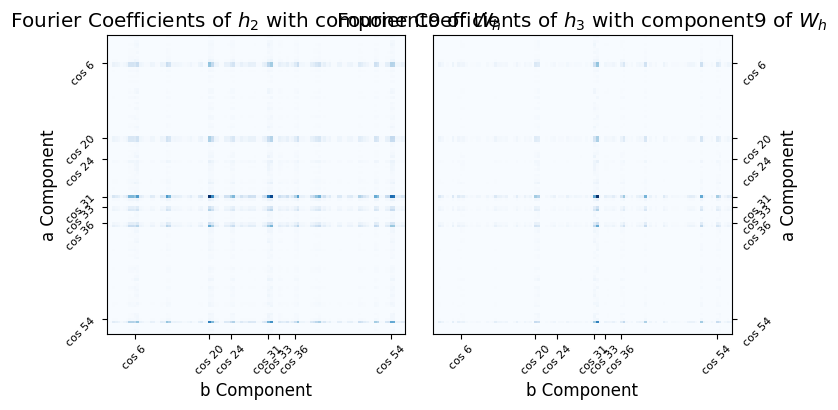

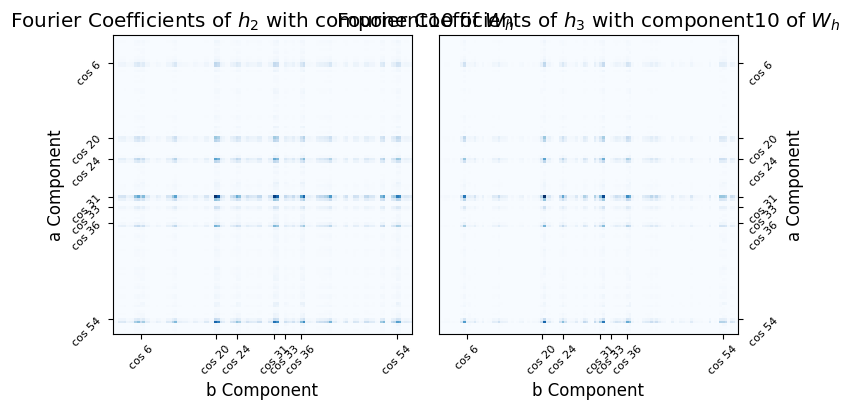

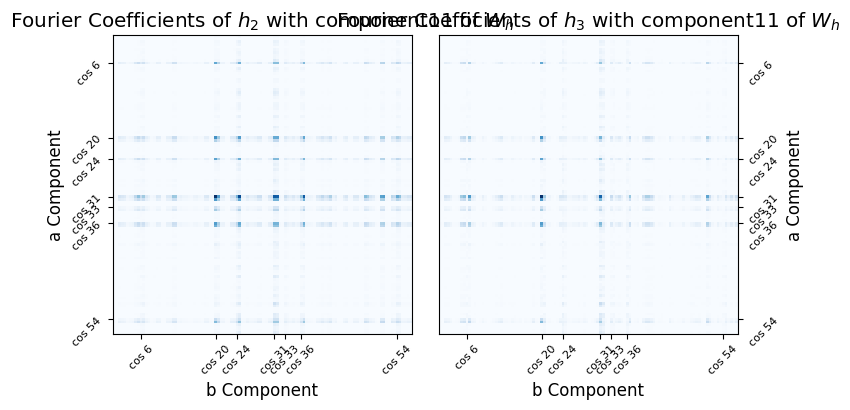

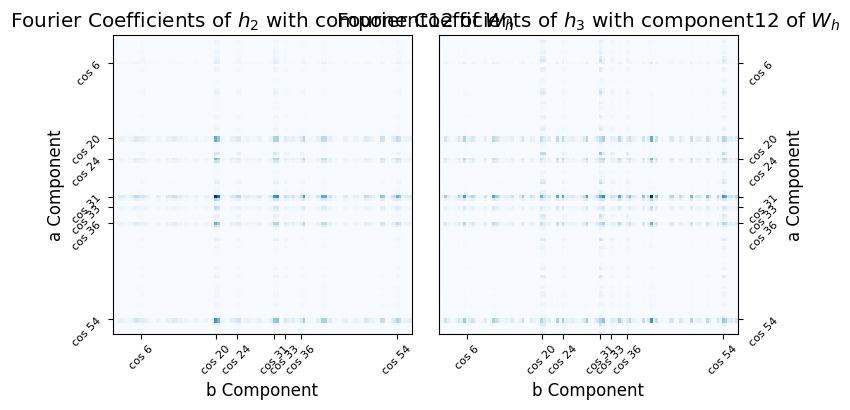

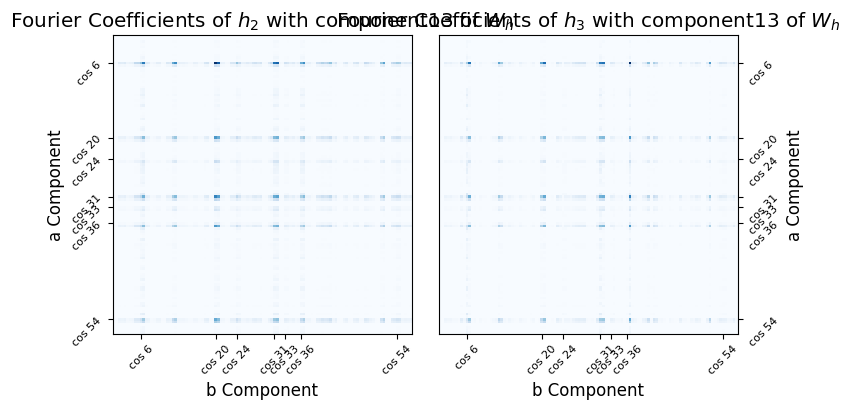

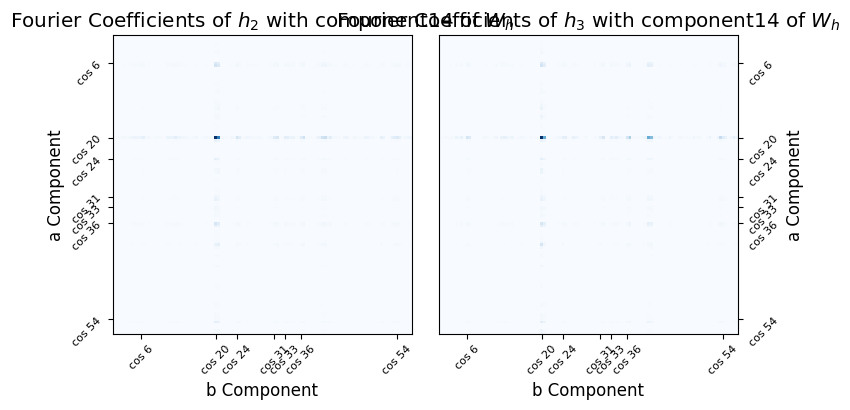

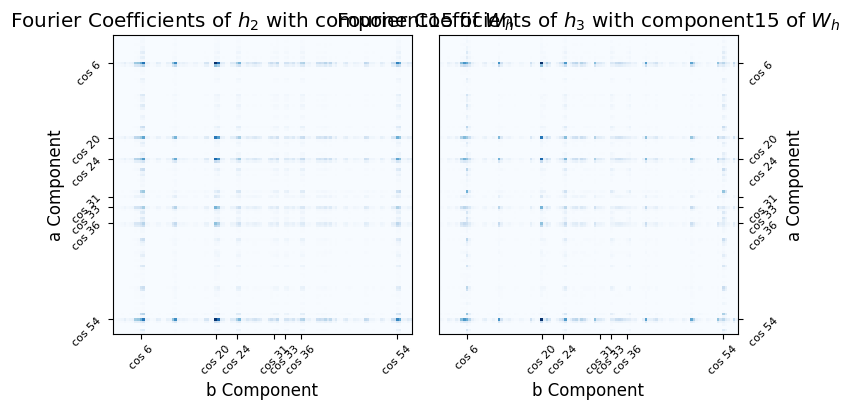

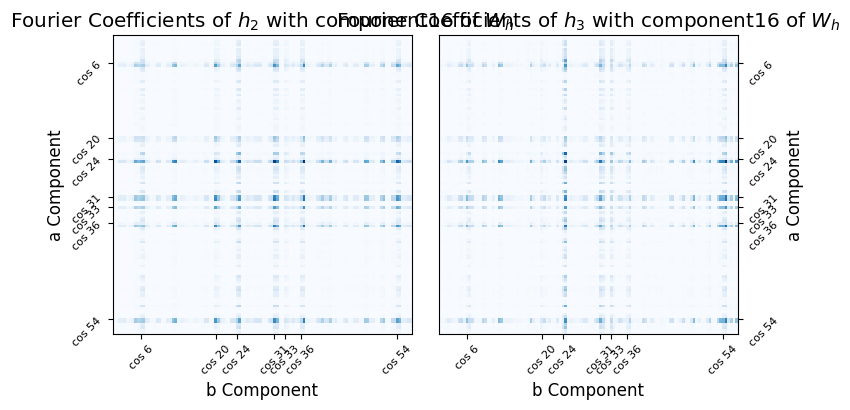

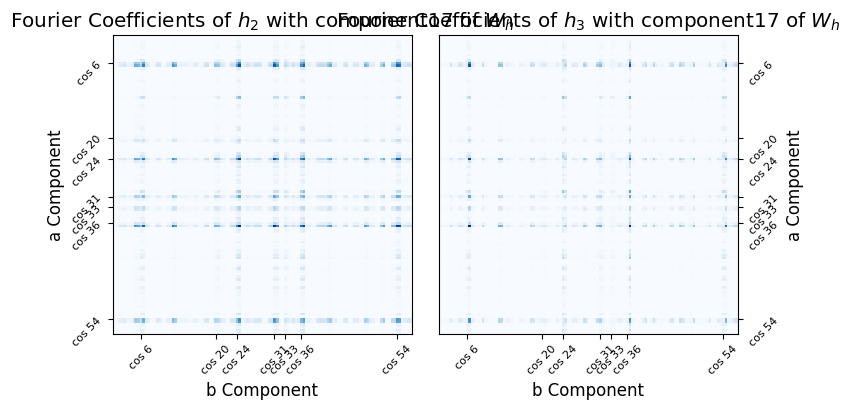

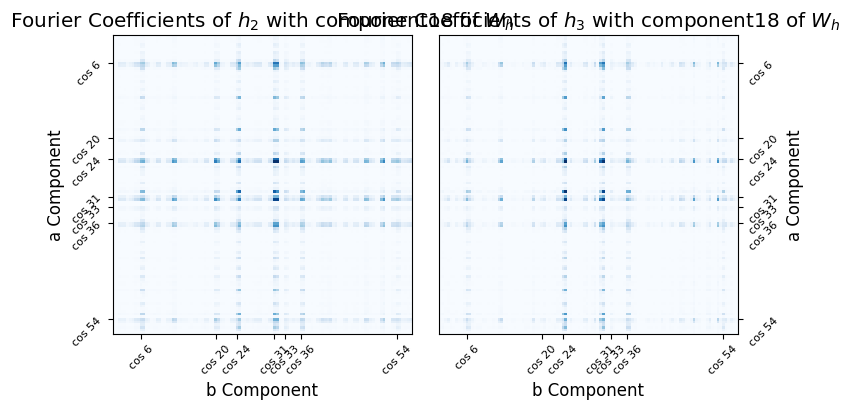

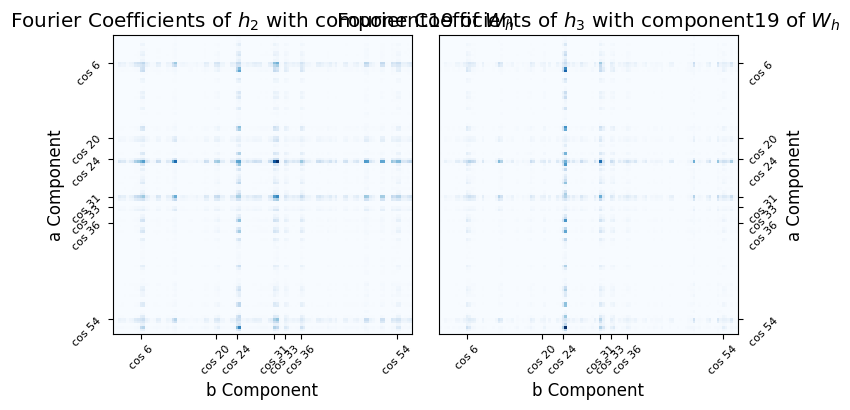

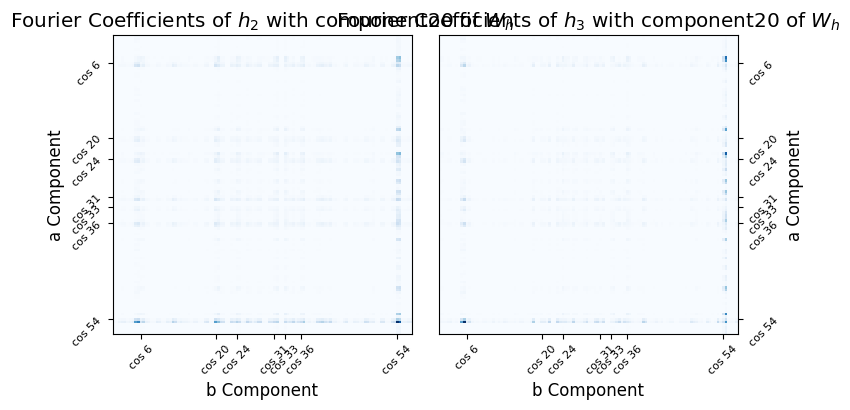

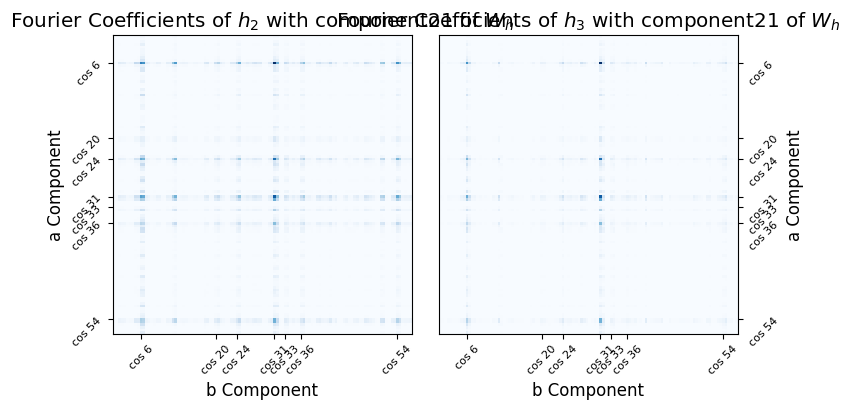

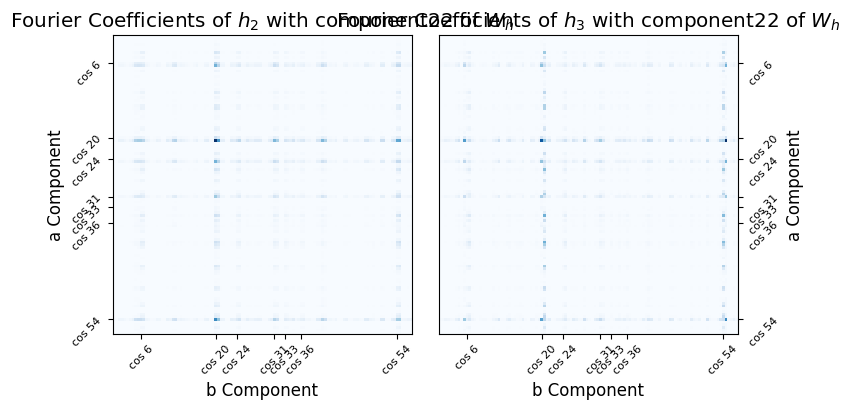

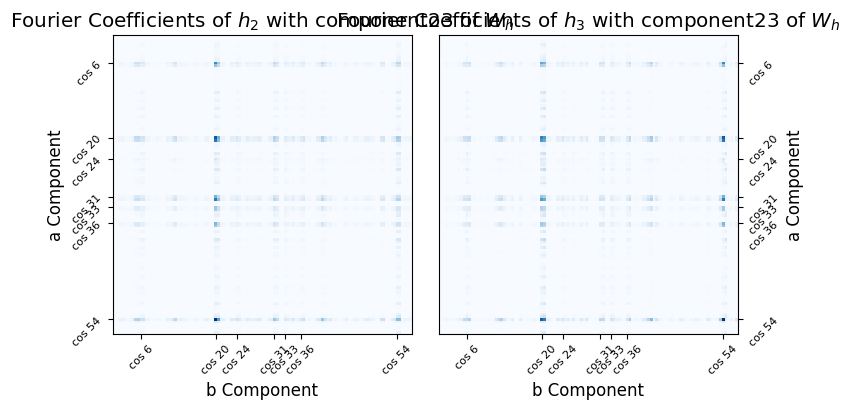

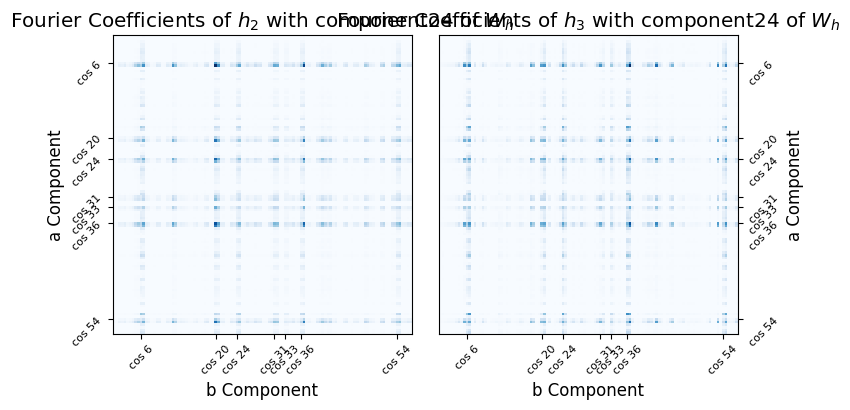

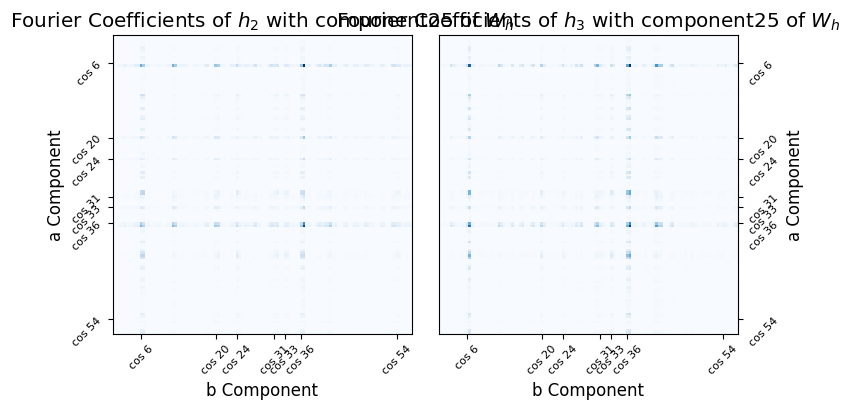

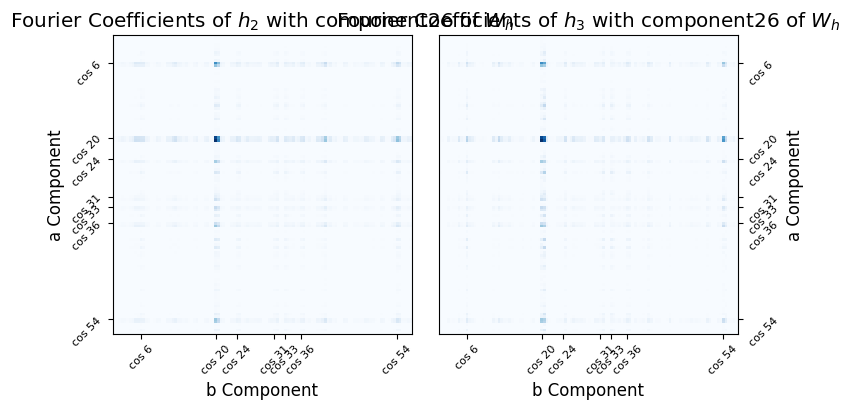

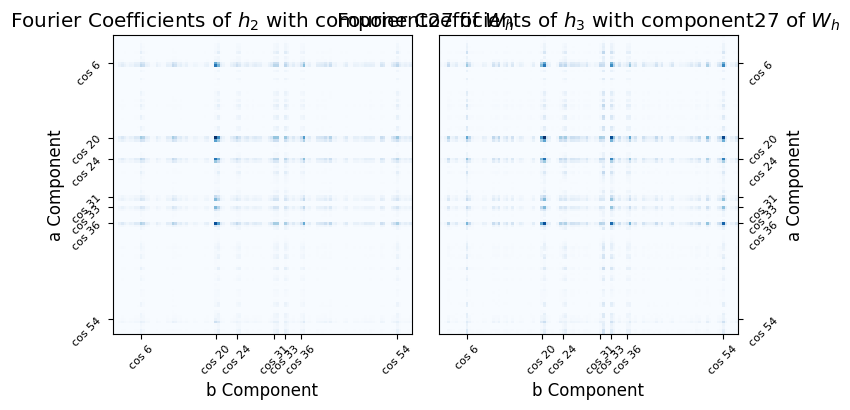

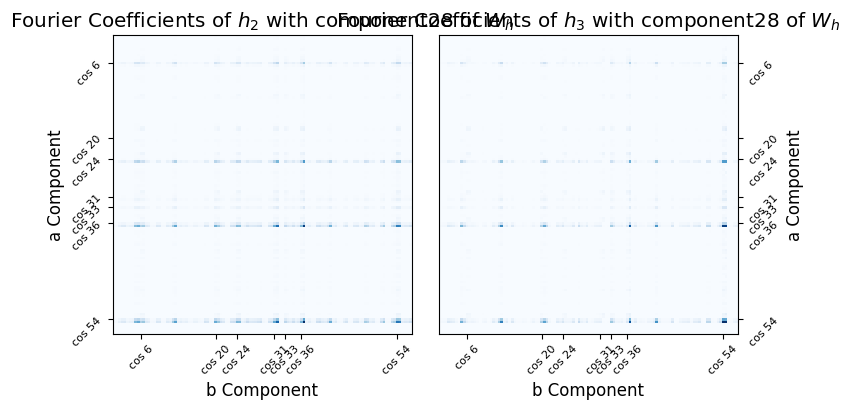

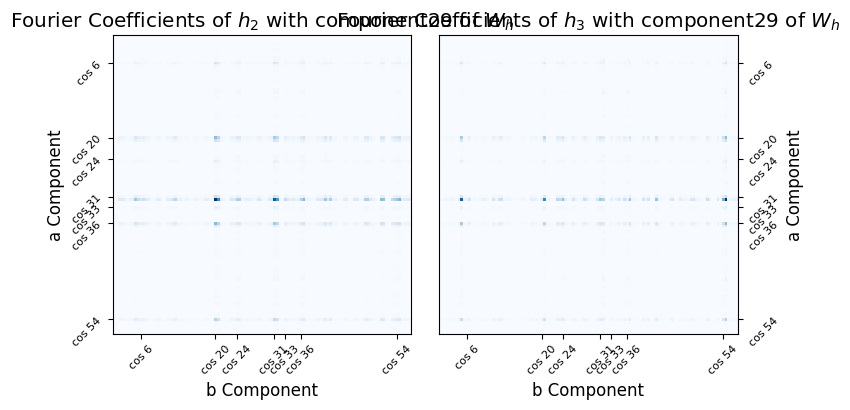

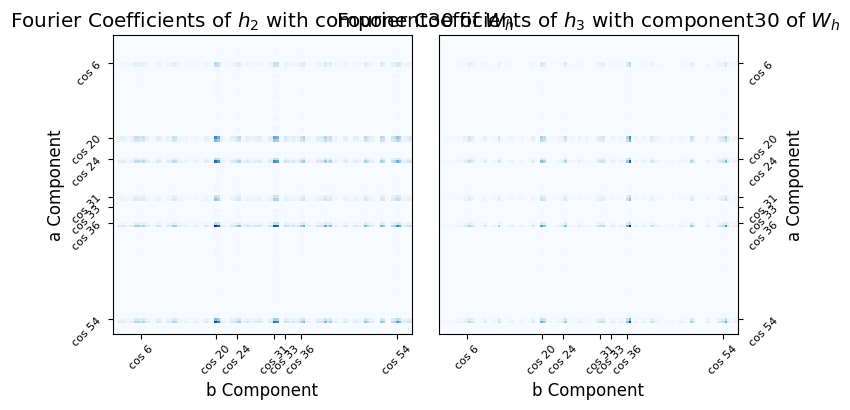

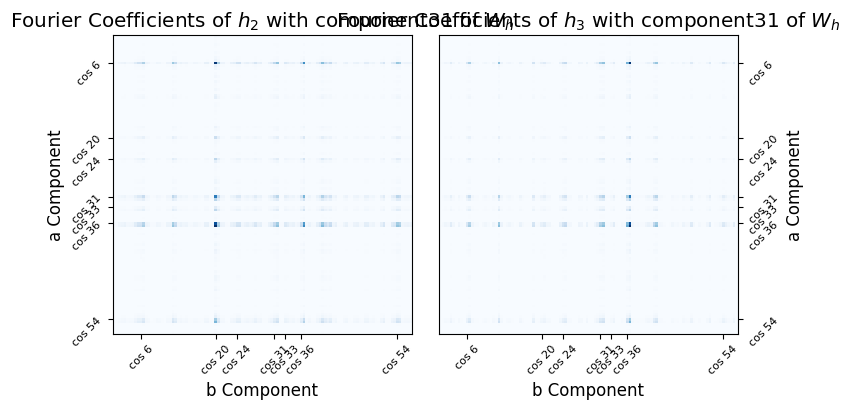

In [33]:
embed_comps = 12
fc_comps = 12
hh_comps = 32

for i in range(hh_comps):
  with torch.no_grad():
    model_weights = deepcopy(cached_data['model'])
    model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
    model_weights['fc.weight'] = U_fc[:,:fc_comps] @ torch.diag(S_fc[:fc_comps]) @ Vh_fc[:fc_comps,:]
    model_weights['rnn.weight_ih_l0'] = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
    # model_weights['rnn.weight_hh_l0'] = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

    W_hh_trunc = S_hh[i] * torch.outer(U_hh[:,i], Vh_hh[i,:])
    model_weights['rnn.weight_hh_l0'] = W_hh_trunc

    model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
    model_trunc.load_state_dict(model_weights)

    embedded_seq = model_trunc.embedding(dataset)
    output, hidden_states = model_trunc.rnn(embedded_seq)
    fourier_transformed_h2 = fft2d(output[:,1,:]).norm(dim=-1).reshape(p,p).detach().numpy()
    fourier_transformed_h3 = fft2d(output[:,2,:]).norm(dim=-1).reshape(p,p).detach().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    # plt.figure(figsize=(4, 4))
    axs[0].matshow(fourier_transformed_h2[1:,1:], cmap='Blues')
    axs[0].set_ylabel('a Component')
    axs[0].xaxis.set_label_position('bottom')
    axs[0].set_xlabel('b Component')
    axs[0].xaxis.tick_bottom()
    axs[0].set_xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
    axs[0].set_yticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
    axs[0].set_title(f'Fourier Coefficients of $h_2$ with component{i} of $W_h$')
    # plt.tight_layout()
    # plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients_h2.pdf')

    # plt.figure(figsize=(4, 4))
    axs[1].matshow(fourier_transformed_h3[1:,1:], cmap='Blues')
    axs[1].yaxis.set_label_position('right')
    axs[1].set_ylabel('a Component')
    axs[1].xaxis.set_label_position('bottom')
    axs[1].set_xlabel('b Component')
    axs[1].xaxis.tick_bottom()
    axs[1].yaxis.tick_right()
    axs[1].set_xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
    axs[1].set_yticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
    axs[1].set_title(f'Fourier Coefficients of $h_3$ with component{i} of $W_h$')

    plt.tight_layout()
    # plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients_h2h3.pdf')
    # plt.show()

[13.568498    8.912734   15.886701   10.0395155   5.262934    9.983799
 13.482703    7.1735682   1.0309047   0.59316576  4.0445952   5.9811535
  7.1944838   9.623012  ]


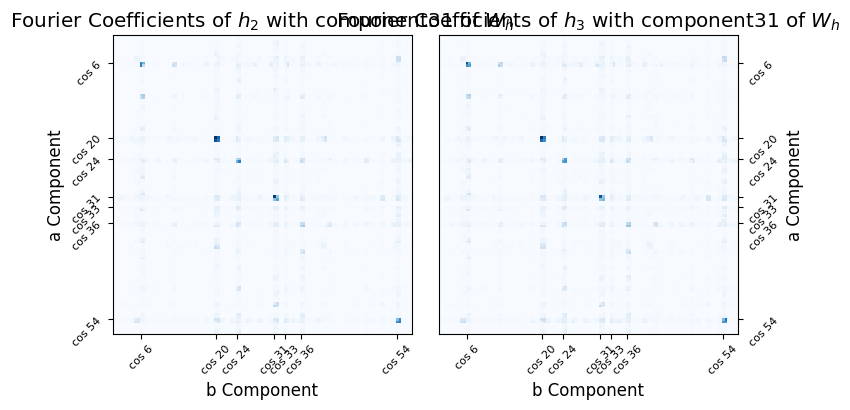

In [34]:
embed_comps = 12
fc_comps = 12
hh_comps = 32

# ablate_idxs = [0,1,10,13,15,18,21,24,30] # 6
# ablate_idxs = [0,1,10,13,14,19, 27] # 15
# ablate_idxs = [0,1,10,11,13,15,16,17,23,24,26] # 20
# ablate_idxs = [0,1,7,8,9,12,13,18,24,25,27,30,31] # 47

with torch.no_grad():
  model_weights = deepcopy(cached_data['model'])
  model_weights['embedding.weight'] = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
  model_weights['fc.weight'] = U_fc[:,:fc_comps] @ torch.diag(S_fc[:fc_comps]) @ Vh_fc[:fc_comps,:]
  model_weights['rnn.weight_ih_l0'] = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
  W_hh_trunc = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

  for j in ablate_idxs:
    W_hh_trunc -= S_hh[j] * torch.outer(U_hh[:,j], Vh_hh[j,:])

  model_weights['rnn.weight_hh_l0'] = W_hh_trunc

  model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
  model_trunc.load_state_dict(model_weights)

  embedded_seq = model_trunc.embedding(dataset)
  output, hidden_states = model_trunc.rnn(embedded_seq)
  fourier_transformed_h2 = fft2d(output[:,1,:]).norm(dim=-1).reshape(p,p).detach().numpy()
  fourier_transformed_h3 = fft2d(output[:,2,:]).norm(dim=-1).reshape(p,p).detach().numpy()

  fig, axs = plt.subplots(1, 2, figsize=(8, 4))

  # plt.figure(figsize=(4, 4))
  axs[0].matshow(fourier_transformed_h2[1:,1:], cmap='Blues')
  axs[0].set_ylabel('a Component')
  axs[0].xaxis.set_label_position('bottom')
  axs[0].set_xlabel('b Component')
  axs[0].xaxis.tick_bottom()
  axs[0].set_xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
  axs[0].set_yticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
  axs[0].set_title(f'Fourier Coefficients of $h_2$ with component{i} of $W_h$')
  # plt.tight_layout()
  # plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients_h2.pdf')

  # plt.figure(figsize=(4, 4))
  axs[1].matshow(fourier_transformed_h3[1:,1:], cmap='Blues')
  axs[1].yaxis.set_label_position('right')
  axs[1].set_ylabel('a Component')
  axs[1].xaxis.set_label_position('bottom')
  axs[1].set_xlabel('b Component')
  axs[1].xaxis.tick_bottom()
  axs[1].yaxis.tick_right()
  axs[1].set_xticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
  axs[1].set_yticks(key_freqs[::2], [fourier_basis_names[i+1] for i in key_freqs[::2]], rotation=45, fontsize=8)
  axs[1].set_title(f'Fourier Coefficients of $h_3$ with component{i} of $W_h$')

  plt.tight_layout()
  print(fourier_transformed_h3[key_freqs+1, key_freqs+1])
  # plt.savefig('drive/MyDrive/workspace/icassp25/fourier_coefficients_h2h3.pdf')
  # plt.show()

In [35]:
embed_comps = 12
fc_comps = 12
hh_comps = 32

E_ablate = [0,2,4,5,11]
ih_ablate = [0,1,2,5]
hh_ablate = [0,1,7,8,9,12,13,18,24,25,27,30,31]
fc_ablate = [0,1]

with torch.no_grad():
  model_weights = deepcopy(cached_data['model'])
  W_E_trunc = U_E[:,:embed_comps] @ torch.diag(S_E[:embed_comps]) @ Vh_E[:embed_comps,:]
  W_fc_trunc = U_fc[:,:fc_comps] @ torch.diag(S_fc[:fc_comps]) @ Vh_fc[:fc_comps,:]
  W_ih_trunc = U_ih[:,:embed_comps] @ torch.diag(S_ih[:embed_comps]) @ Vh_ih[:embed_comps,:]
  W_hh_trunc = U_hh[:,:hh_comps] @ torch.diag(S_hh[:hh_comps]) @ Vh_hh[:hh_comps,:]

  for j in E_ablate:
    W_E_trunc -= S_E[j] * torch.outer(U_E[:,j], Vh_E[j,:])
  model_weights['embedding.weight'] = W_E_trunc

  for j in ih_ablate:
    W_ih_trunc -= S_ih[j] * torch.outer(U_ih[:,j], Vh_ih[j,:])
  model_weights['rnn.weight_ih_l0'] = W_ih_trunc

  for j in hh_ablate:
    W_hh_trunc -= S_hh[j] * torch.outer(U_hh[:,j], Vh_hh[j,:])
  model_weights['rnn.weight_hh_l0'] = W_hh_trunc

  for j in fc_ablate:
    W_fc_trunc -= S_fc[j] * torch.outer(U_fc[:,j], Vh_fc[j,:])
  model_weights['fc.weight'] = W_fc_trunc

  model_trunc = RNNModel(HIDDEN_DIM, NUM_HIDDEN_LAYERS, MODULO+1)
  model_trunc.load_state_dict(model_weights)

  evaluation_trunc = evaluate(model_trunc, dataset, labels)
  print(f"Accuracy after ablating freq 47: {evaluation_trunc}%")

Accuracy after ablating freq 47: 0.8614613517111754%
